# Demo for the ProblemsSolvers class.

This script is intended to help with debugging problems and solvers.

It create problem-solver groups (using the directory) and runs multiple macroreplications of each problem-solver pair.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [1]:
import sys
from pathlib import Path

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [2]:
# Specify the names of the solver(s) and problem(s) to test.
#solver_abbr_names = [ "SQPASTRODF"]
solver_abbr_names = ["SQPASTRODF", "COBYQA"]
problem_abbr_names = ["SAN-3"]
solver_factors = [{"easy_solve": False, "use_gradients":False, "sigma_min": 0.1, "sigma_b_max":100},{"sample_size": 30}]
#solver_factors = [{}]
problem_factors = [{"budget":50000, "total_cost": 5.0}]

num_macroreps = 10
num_postreps = 50
num_postreps_init_opt = 50

In [3]:
# Initialize an instance of the experiment class.
from simopt.experiment_base import ProblemsSolvers

mymetaexperiment = ProblemsSolvers(
    solver_names=solver_abbr_names, problem_names=problem_abbr_names, solver_factors = solver_factors, problem_factors = problem_factors
)

# Write to log file.
mymetaexperiment.log_group_experiment_results()

In [4]:
# Run a fixed number of macroreplications of each solver on each problem.
mymetaexperiment.run(n_macroreps=num_macroreps)

In [5]:
print("Post-processing results.")
# Run a fixed number of postreplications at all recommended solutions.
mymetaexperiment.post_replicate(n_postreps=num_postreps)

Post-processing results.


In [6]:
print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
mymetaexperiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

Post-normalizing results.


In [7]:
mymetaexperiment.report_group_statistics()

Plotting results...
Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SOLVER_SET_SAN-3_all_prog_curves_unnorm.png')]
Plotting complete!


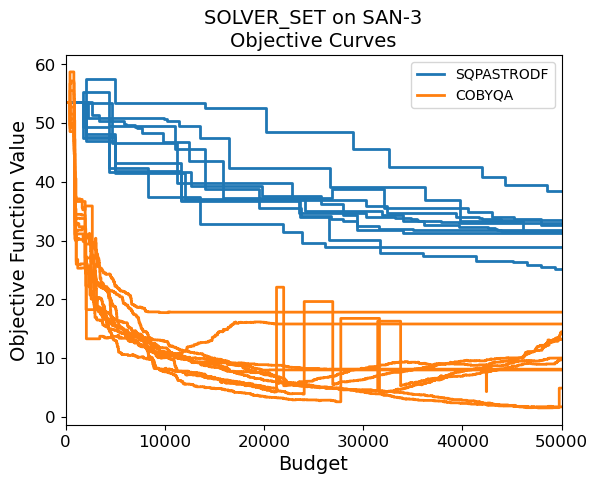

In [8]:
# Produce basic plots.

from simopt.experiment_base import (
    plot_area_scatterplots,  # noqa: F401
    plot_feasibility_progress,  # noqa: F401
    plot_progress_curves,  # noqa: F401
    plot_solvability_cdfs,  # noqa: F401
    plot_solvability_profiles,  # noqa: F401
    plot_terminal_feasibility,  # noqa: F401
    plot_terminal_progress,  # noqa: F401
    plot_terminal_scatterplots, 
    plot_det_feasibility,
    plot_det_terminal_feasibility,
    PlotType # noqa: F401
)

print("Plotting results...")


def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_progress_curves(
        experiments=mymetaexperiment.experiments[0] + mymetaexperiment.experiments[1] , plot_type=PlotType.ALL, normalize=False
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SQPASTRODF_SAN-3_all_prog_curves_unnorm.png'), WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/COBYQA_SAN-3_all_prog_curves_unnorm.png')]
Plotting complete!


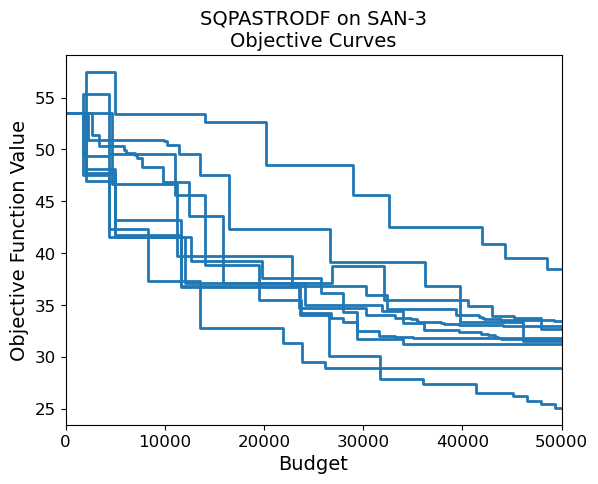

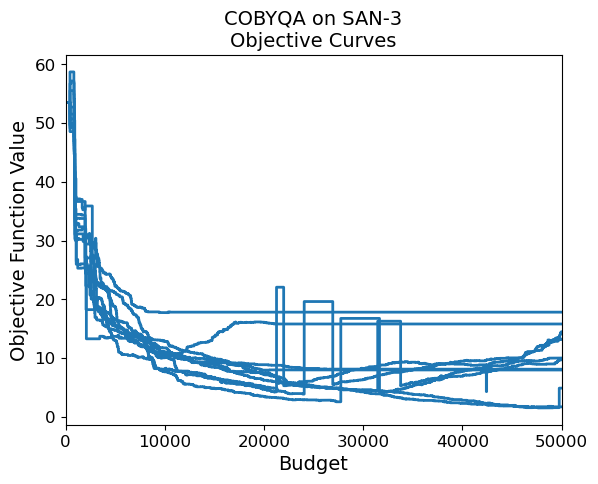

In [9]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_progress_curves(
        experiments=mymetaexperiment.experiments[0] + mymetaexperiment.experiments[1], all_in_one = False, plot_type=PlotType.ALL, normalize=False
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SOLVER_SET_SAN-3_terminal_violin.png')]
Plotting complete!


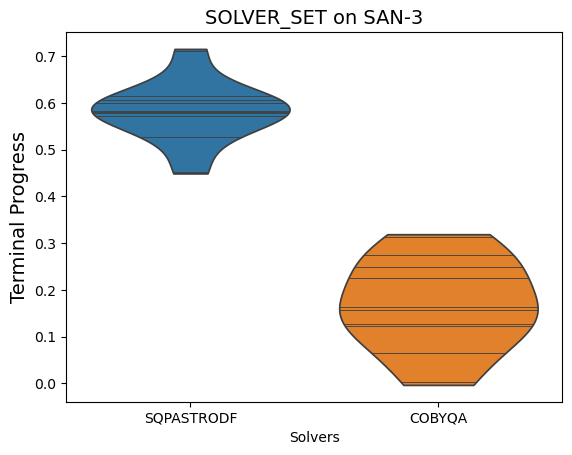

In [10]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_terminal_progress(
        experiments=mymetaexperiment.experiments[0] + mymetaexperiment.experiments[1]
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SOLVER_SET_SAN-3_det_feasibility_progress_unnorm.png')]
Plotting complete!


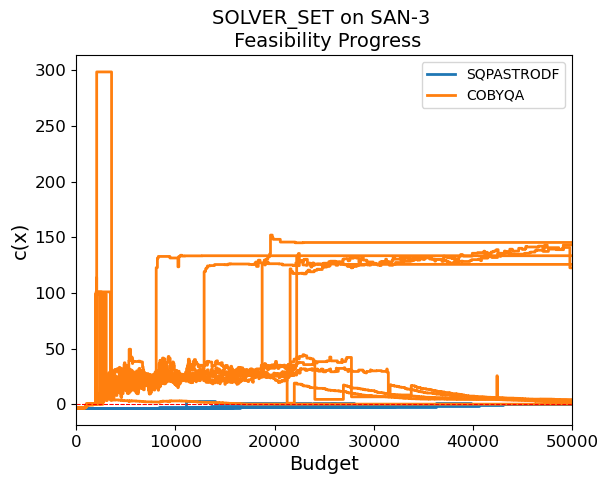

In [11]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments, 
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SOLVER_SET_SAN-3_det_feasibility_progress_unnorm (1).png')]
Plotting complete!


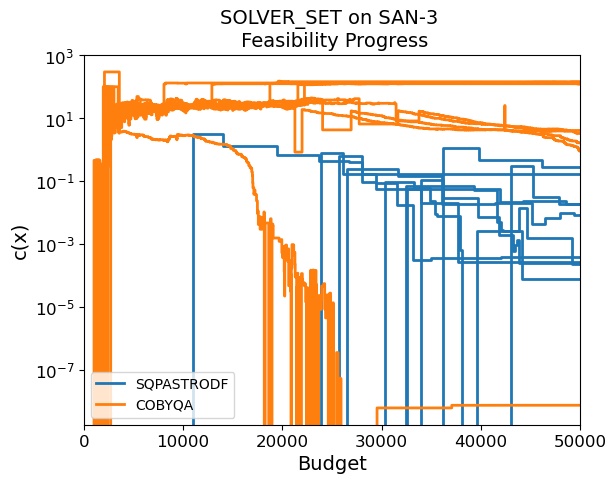

In [12]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments, log_scale = True, log_base = 10
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SOLVER_SET_SAN-3_det_feasibility_progress_unnorm (1) (2).png')]
Plotting complete!


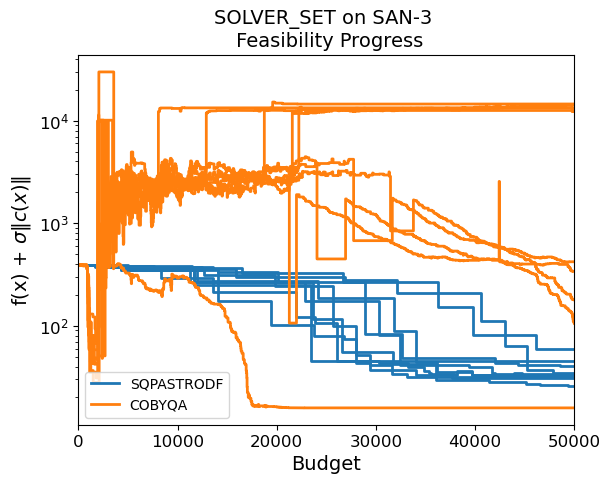

In [13]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments, log_scale = True, score_type = "objective", obj_const = 100
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SOLVER_SET_SAN-3_det_feasibility_progress_unnorm (1) (2) (3).png')]
Plotting complete!


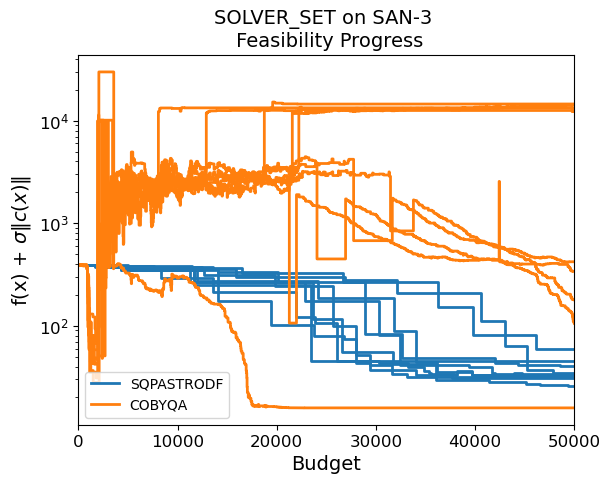

In [14]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments, log_scale = True, score_type = "objective"
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SOLVER_SET_SAN-3_det_feasibility_progress_unnorm (1) (2) (3) (4).png')]
Plotting complete!


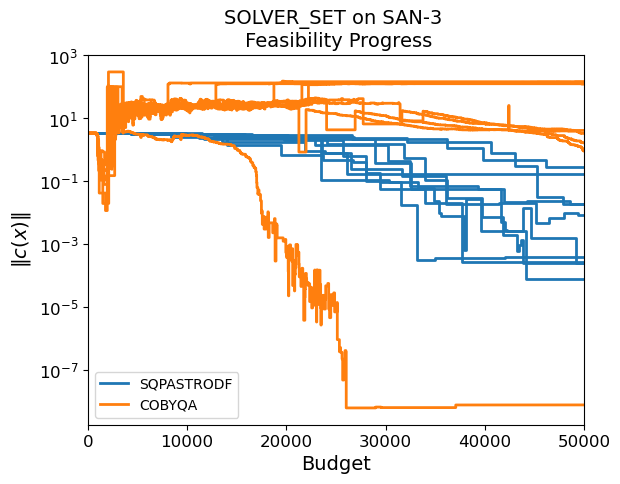

In [15]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_feasibility(
        experiments=mymetaexperiment.experiments, log_scale = True, score_type = "norm"
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SOLVER_SET_SAN-3_det_feasibility_scatter_unnorm.png')]
Plotting complete!


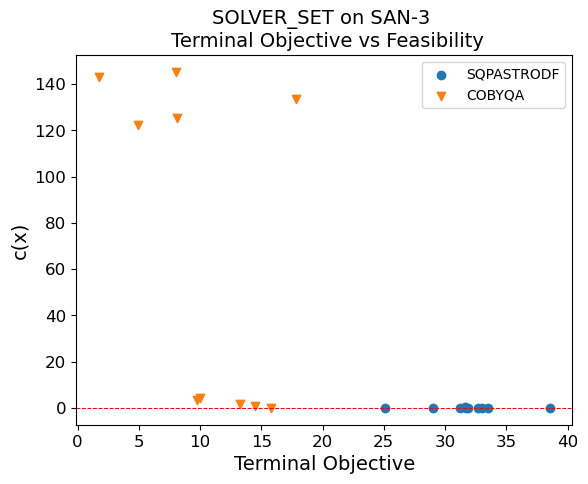

In [16]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_terminal_feasibility(
        experiments=mymetaexperiment.experiments, all_in_one = True, plot_conf_ints = False, score_type = "value"
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SOLVER_SET_SAN-3_det_feasibility_scatter_unnorm (1).png')]
Plotting complete!


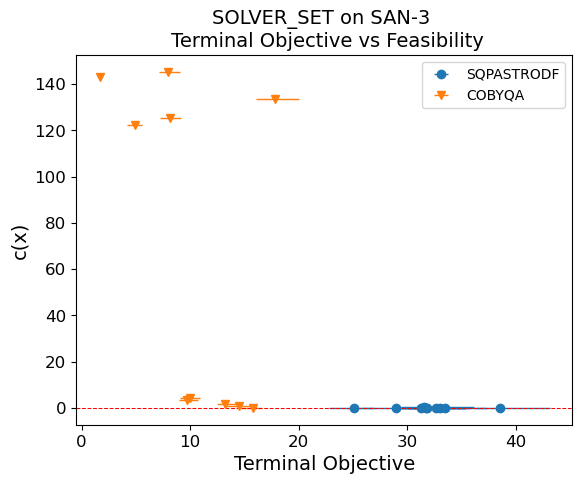

In [17]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_terminal_feasibility(
        experiments=mymetaexperiment.experiments, all_in_one = True, plot_conf_ints = True
    )
)

print("Plotting complete!")

Plot saved to [WindowsPath('C:/Users/nikki/GitHub/simopt/notebooks/experiments/2026-06-17_18-52-17/plots/SOLVER_SET_SAN-3_det_feasibility_scatter_unnorm (1) (2).png')]
Plotting complete!


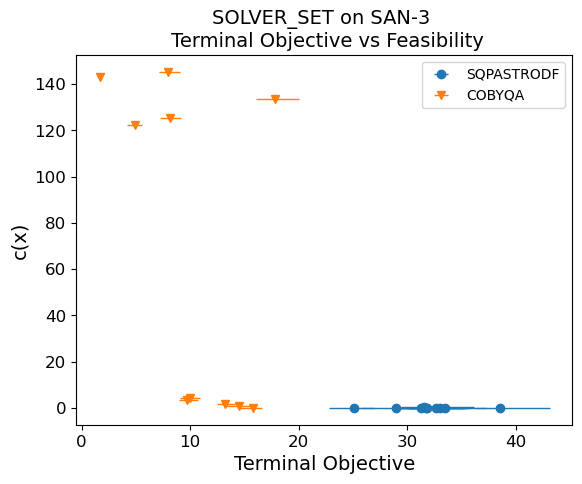

In [18]:
def _print_path(plot_path: list[Path]) -> None:
    print(f"Plot saved to {plot_path!s}")


_print_path(
    plot_det_terminal_feasibility(
        experiments=mymetaexperiment.experiments, all_in_one = True, plot_conf_ints = True,  plot_zero = False
    )
)

print("Plotting complete!")